In [1]:
import pandas as pd
import duckdb as db
import matplotlib.pyplot as plt

from datetime import datetime
from prophet import Prophet

from prophet.plot import plot_plotly, plot_components_plotly  

/home/jose/dashboard/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
df = pd.read_csv('../../../data/TrafficPerTerritory.csv')

In [25]:
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m-%d")

In [26]:
df_plot = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & (df['IslandId'] == 0) & (df['StopoverTerritoryId'] == 9)].copy(deep=True)

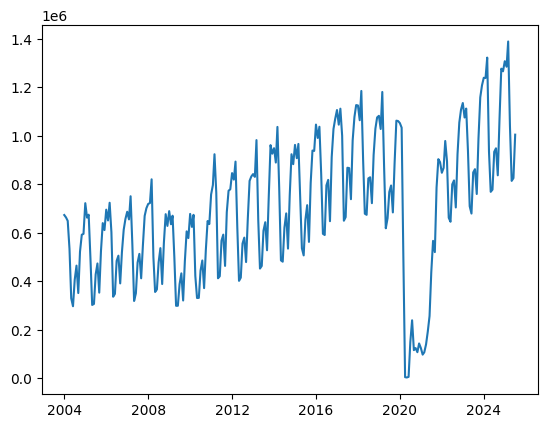

In [27]:
plt.plot(df_plot['Month'], df_plot['Passengers'])

## Testing

As we can see in the plot above, COVID created an outlier period in the data. To handle this we will use the Prophet model and set those values to None, this way the model will handle the missing data automatically by interpolating through the period withouth letting it affect the model's understanding of normal patterns

In [32]:
# Total Passengers that arrive to Gran Canaria per month
df_prophet = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & (df['IslandId'] == 6)].copy(deep=True)

In [33]:
s = df_prophet.groupby(['Month']).sum()

In [34]:
s

,IslandId,StopoverTerritoryId,AircraftMovementId,AirServiceId,Passengers,Operations,Goods,Mail
Month,,,,,,,,
2004-01-01,30,42,10,0,73027,1470,117336,4102
2004-02-01,30,42,10,0,75485,1339,137275,4022
2004-03-01,30,42,10,0,81473,1438,155723,5175
2004-04-01,30,42,10,0,85712,1546,126441,5721
2004-05-01,30,42,10,0,69713,1450,114683,4001
...,...,...,...,...,...,...,...,...
2025-03-01,30,42,10,0,139843,2146,23402,0
2025-04-01,30,42,10,0,128904,1881,21788,0
2025-05-01,30,42,10,0,117374,1835,20053,0


In [35]:
df_prophet = s[['Passengers']].copy(deep=True)


df_prophet.reset_index(inplace=True)

df_prophet.rename({'Month': 'ds', 'Passengers': 'y'}, axis=1, inplace=True)

In [36]:
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      259 non-null    datetime64[ns]
 1   y       259 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.2 KB


In [37]:
df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01'), 'y'] = None

In [38]:
df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01')]

,ds,y
194,2020-03-01,NaN
195,2020-04-01,NaN
196,2020-05-01,NaN
197,2020-06-01,NaN
198,2020-07-01,NaN
199,2020-08-01,NaN
200,2020-09-01,NaN
201,2020-10-01,NaN
202,2020-11-01,NaN
203,2020-12-01,NaN


In [39]:
m = Prophet()
m.fit(df_prophet)

22:13:54 - cmdstanpy - INFO - Chain [1] start processing
22:13:54 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
future = m.make_future_dataframe(periods=12, freq='MS') 

In [41]:
forecast = m.predict(future)

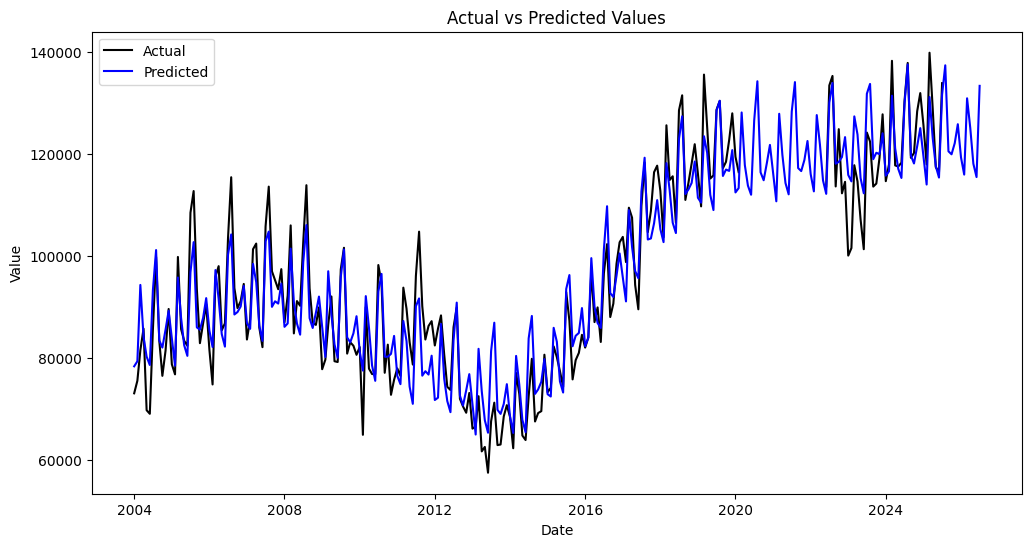

In [42]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual', color='black')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='blue')
plt.legend()
plt.title('Actual vs Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

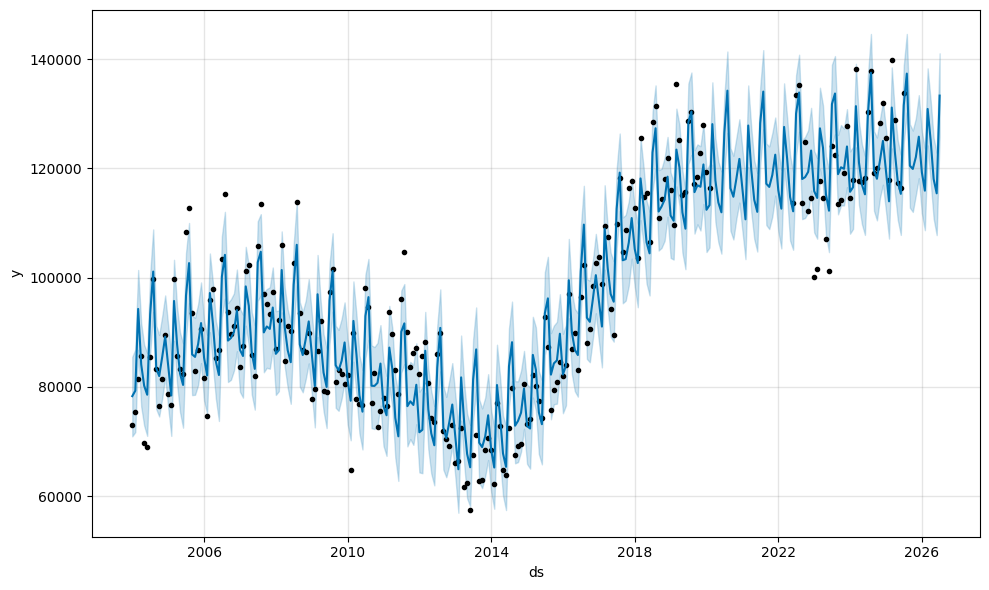

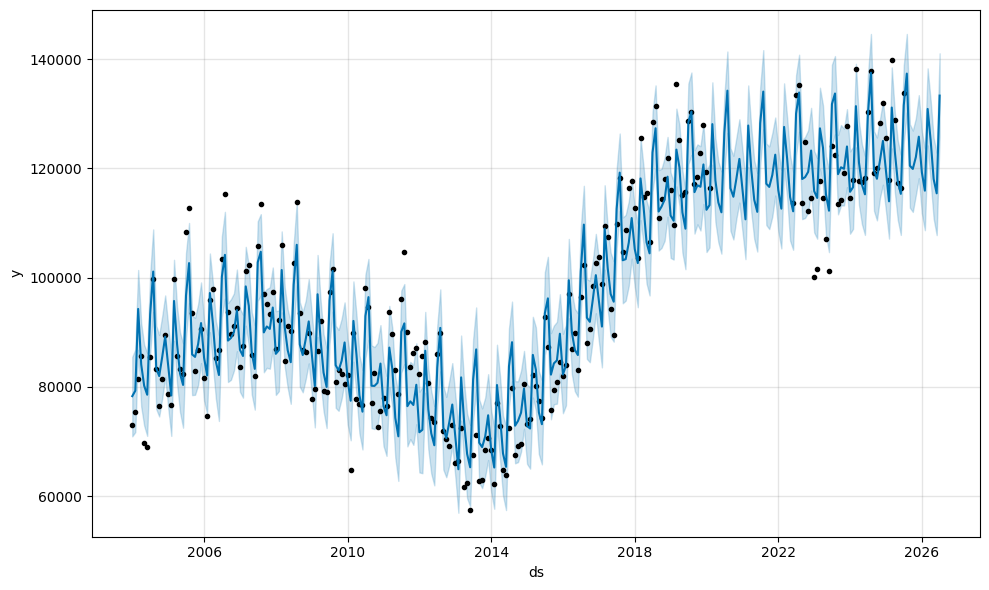

In [43]:
m.plot(forecast)

## Pipeline

In [48]:
islands_id = [0, 1, 2, 3, 4, 5, 6, 7]
predictions_for_each_island = []
real_for_each_island = []

for island_id in islands_id:
    df_prophet = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & 
                            (df['IslandId'] == island_id)].copy(deep=True)
    df_prophet = df_prophet.groupby('Month').sum()[['Passengers']].copy(deep=True)
    df_prophet.reset_index(inplace=True)
    df_prophet.rename({'Month': 'ds', 'Passengers': 'y'}, axis=1, inplace=True)
    df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01'), 'y'] = None
    real_for_each_island.append(df_prophet)
    m = Prophet()
    m.fit(df_prophet)
    future = m.make_future_dataframe(periods=12, freq='MS') 
    predictions_for_each_island.append((island_id, m.predict(future)[['ds', 'yhat_lower', 'yhat', 'yhat_upper']]))

    

22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing
22:16:55 - cmdstanpy - INFO - Chain [1] start processing
22:16:55 - cmdstanpy - INFO - Chain [1] done processing


0


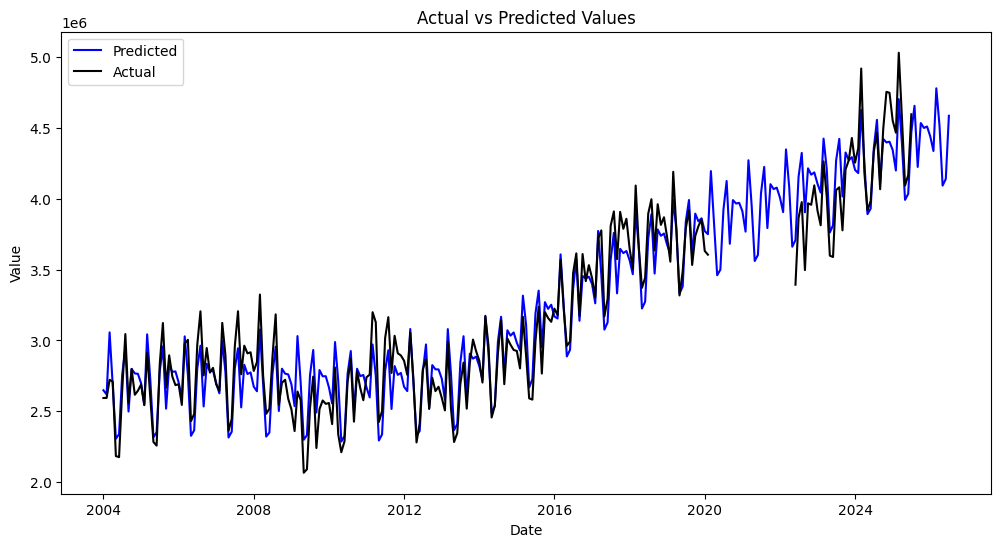

1


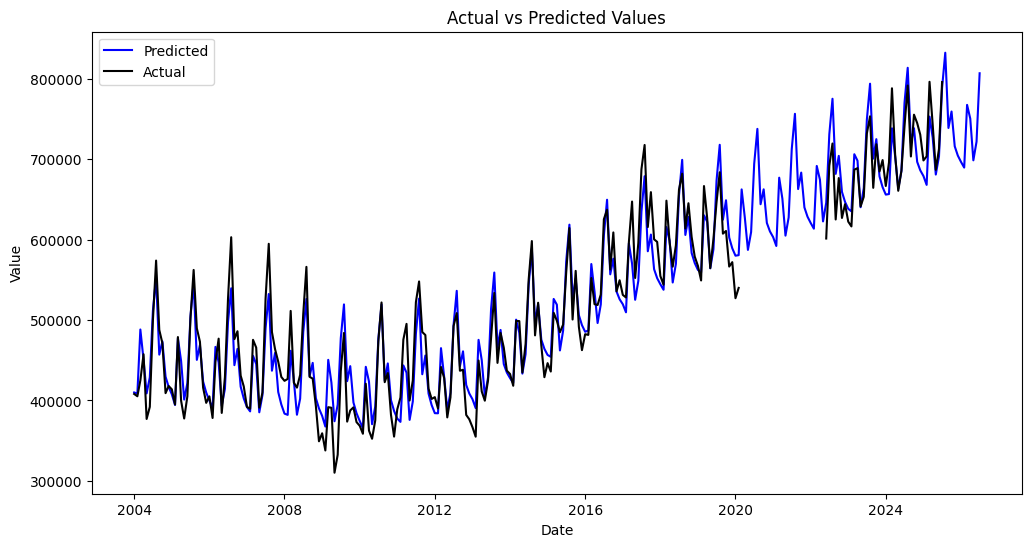

2


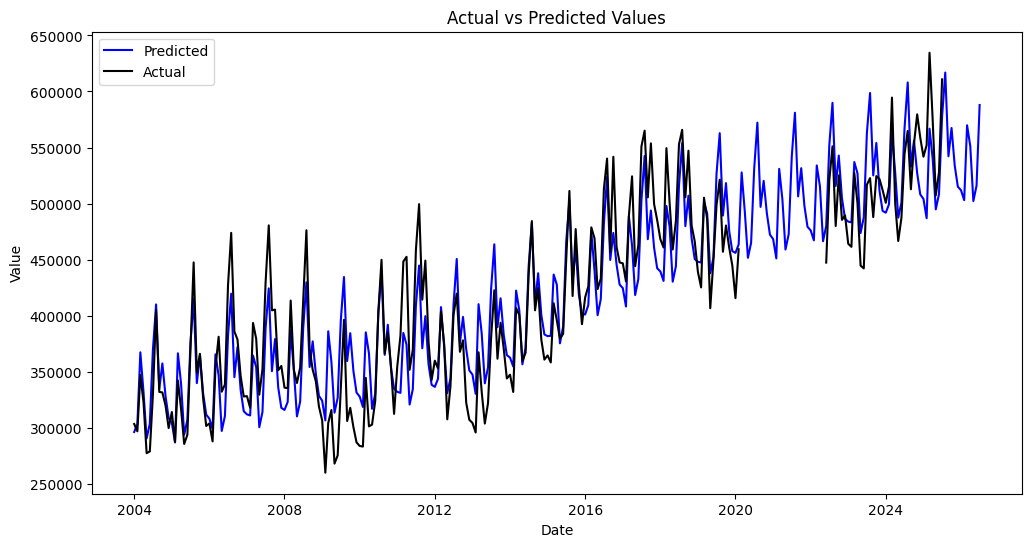

3


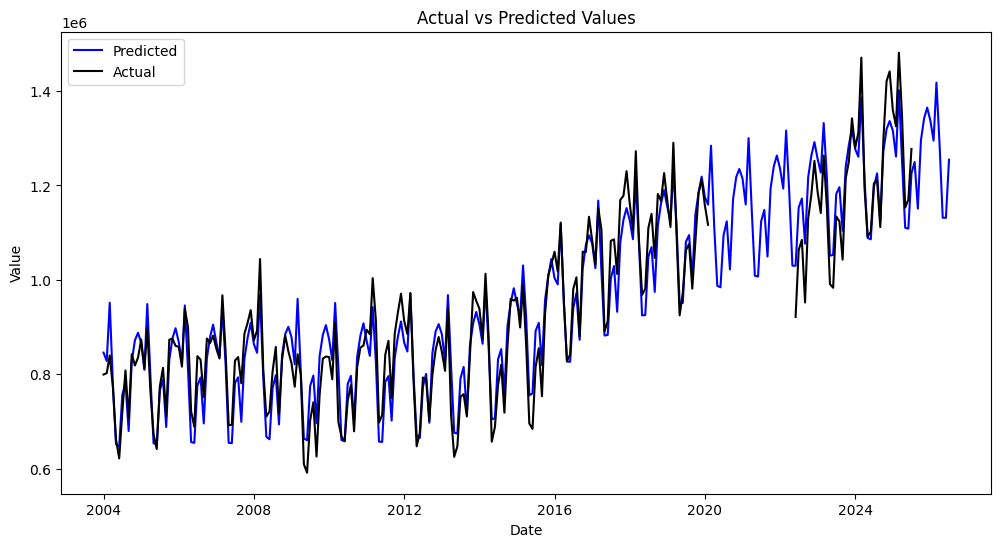

4


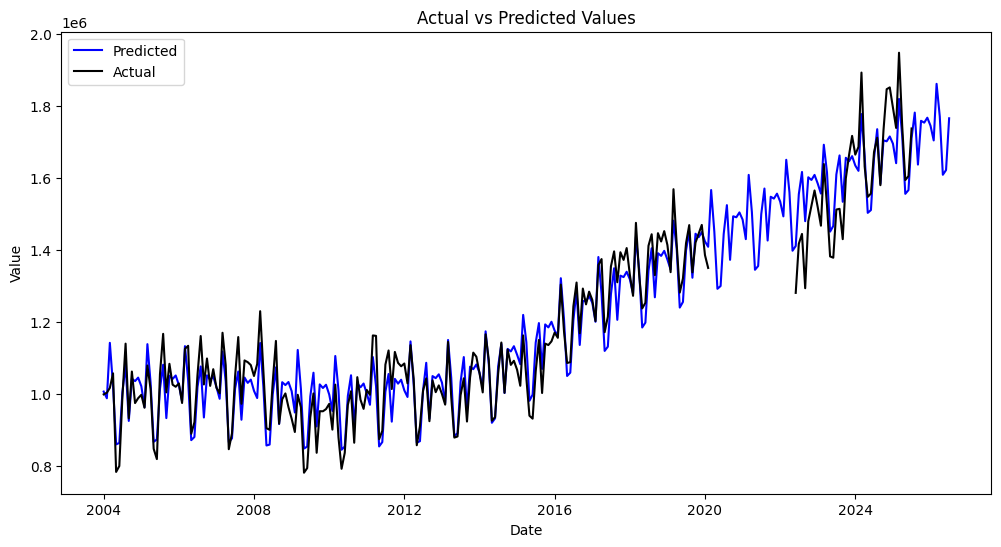

5


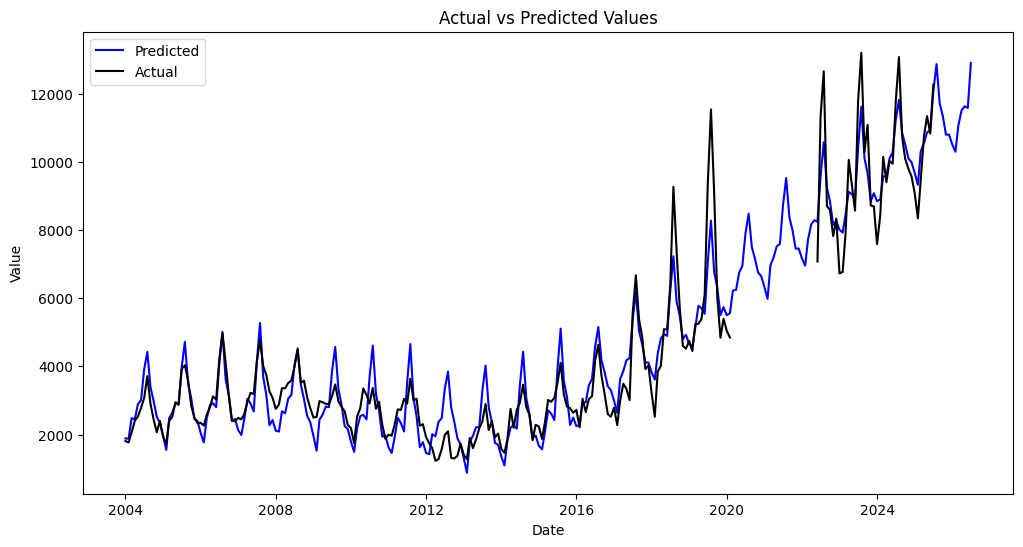

6


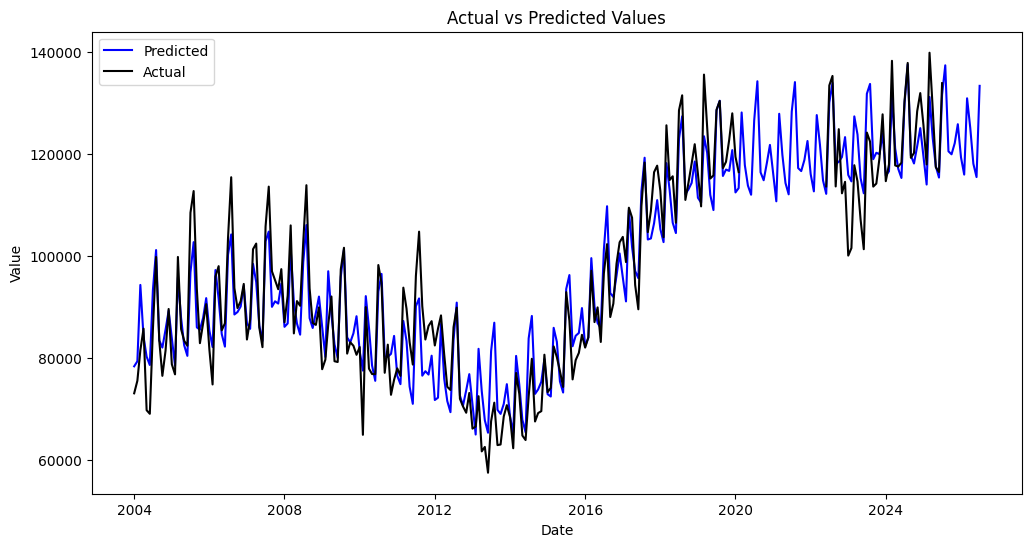

7


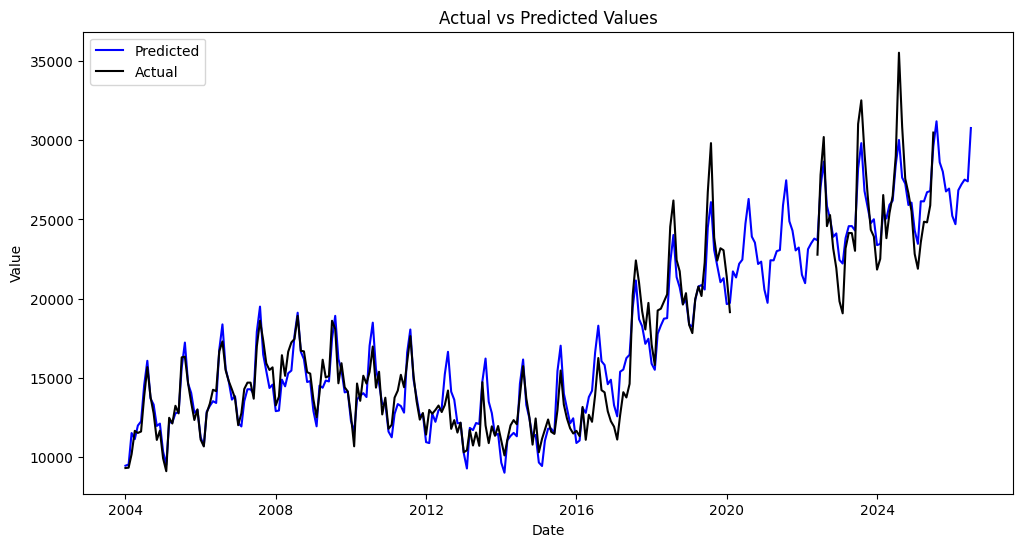

In [49]:
for pr in predictions_for_each_island:
    island_id = pr[0]
    pred = pr[1]
    print(island_id)
    # Plot actual vs predicted
    plt.figure(figsize=(12, 6))
    plt.plot(pred['ds'], pred['yhat'], label='Predicted', color='blue')
    plt.plot(real_for_each_island[island_id]['ds'], real_for_each_island[island_id]['y'], label='Actual', color='black')
    plt.legend()
    plt.title('Actual vs Predicted Values')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.show()

In [47]:
predictions_for_each_island[-1]

(7,
             ds    yhat_lower          yhat    yhat_upper
 0   2004-01-01   7901.714784   9464.422354  11158.880203
 1   2004-02-01   7949.468115   9539.835345  11158.753909
 2   2004-03-01   9889.258885  11523.907150  13193.201020
 3   2004-04-01   9547.375711  11140.108740  12727.614438
 4   2004-05-01  10379.689264  11999.089876  13580.449521
 ..         ...           ...           ...           ...
 266 2026-03-01  25087.514204  26842.068444  28441.106400
 267 2026-04-01  25590.820673  27217.822387  28869.627714
 268 2026-05-01  25784.541361  27511.592340  29196.667263
 269 2026-06-01  25791.556558  27402.103512  28903.991976
 270 2026-07-01  29015.991573  30766.241587  32495.280708
 
 [271 rows x 4 columns])